# Part II - Ford GoBike System Data Analysis
## by Hanna Abudayeh

## Investigation Overview


> This analysis explores the Ford GoBike System dataset to uncover key patterns in user behavior, trip durations, and demographic trends. The dataset includes detailed information on bike-sharing trips, such as duration, user type, gender, and age.

> The goal is to understand how trip characteristics vary across different user groups and identify the factors that influence ride length and usage patterns. These insights can support data-driven decisions to enhance service operations and improve the overall user experience.

**key Insights**
*   Trip Duration by User Type: Customers tend to take longer trips than Subscribers, suggesting casual use versus routine commuting.

*   Gender Patterns: Male users account for most trips, while female Customers
tend to have slightly longer ride durations on average.

*   Age and Usage: The system is most popular among users aged 20–40, with older users showing more varied trip lengths.

*   Bike Share Program: Participants in the "Bike Share for All" program generally take shorter trips, likely reflecting regular, utility-based usage.

## Dataset Overview and Executive Summary

> The Ford GoBike System dataset captures detailed information about individual bike-sharing trips in the San Francisco Bay Area. It includes variables such as trip duration, start and end times, user type (Subscriber or Customer), gender, birth year, and participation in the "Bike Share for All" program.

>This data enables analysis of user behavior, trip patterns, and demographic trends to uncover insights that can guide operational improvements and enhance the user experience.

**Key Features of the Dataset**
*  Trip Details:
Includes variables such as duration_sec, start_time, end_time, start_station, and end_station to capture ride-specific information.

*  User Information:
Captures demographic details including user_type (Subscriber or Customer), member_gender, and member_birth_year.

*  Program Participation:
The bike_share_for_all_trip column indicates whether a user is enrolled in the "Bike Share for All" program, providing additional behavioral context.



In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
# load in the dataset into a pandas dataframe
df = pd.read_csv('201902-fordgobike-tripdata.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

## (Visualization 1) Trip Duration by Gender and User Type


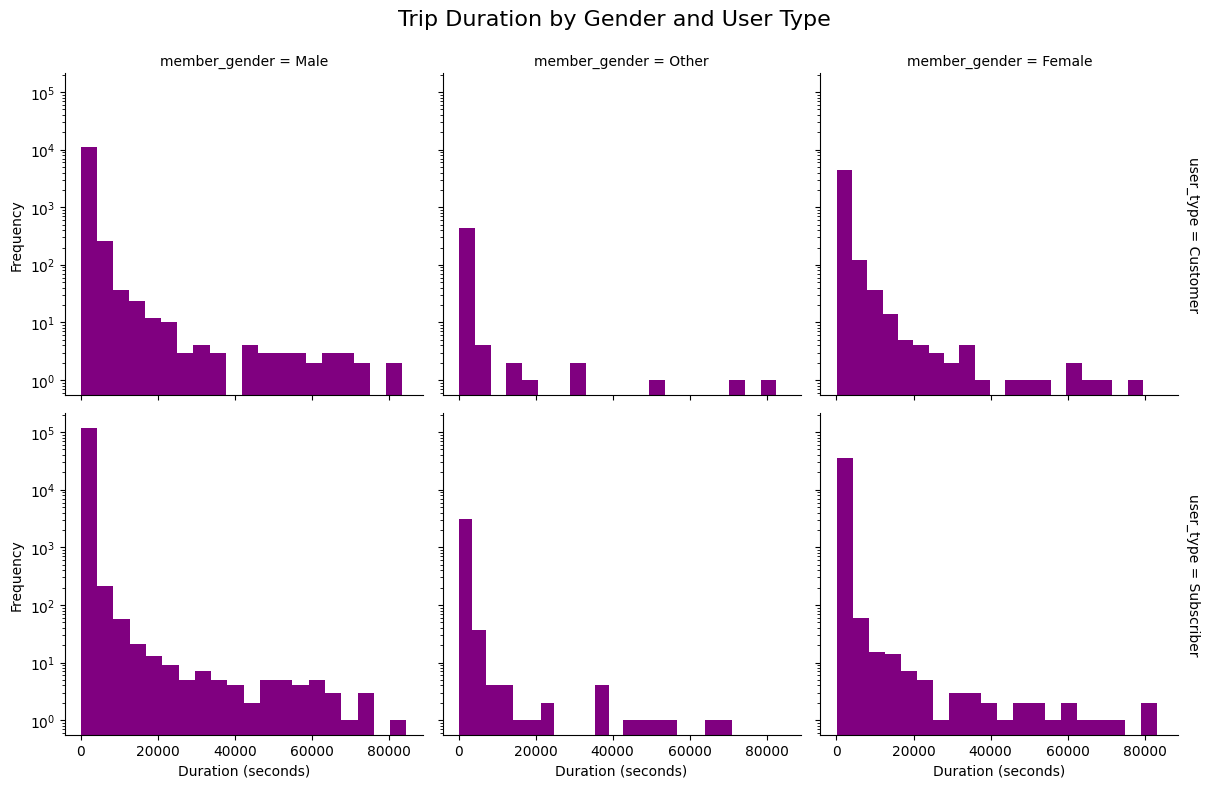

In [7]:
# Visualization 12: Trip Duration by Gender and User Type
facet = sns.FacetGrid(df, col='member_gender', row='user_type', margin_titles=True, height=4)
facet.map(plt.hist, 'duration_sec', bins=20, color='purple', log=True)
facet.set_axis_labels('Duration (seconds)', 'Frequency')
facet.fig.subplots_adjust(top=0.9)
facet.fig.suptitle('Trip Duration by Gender and User Type', fontsize=16)
plt.show()

 Comment:
This facet grid histogram displays the distribution of trip durations segmented by gender and user type (Subscriber vs. Customer). Key insights include:

*   Customers consistently exhibit longer trip durations across all gender groups, suggesting more casual or recreational use.

*   Subscribers show shorter, more concentrated trip durations, reflecting routine or commuting behavior.

*   Male users represent the majority of trips in both user types, while female and other gender categories account for a smaller share.

This visualization highlights notable differences in trip behavior across gender and user groups.

## (Visualization 2) User Type and Gender Distribution

> You should have at least three visualizations in your presentation, but feel free to add more if you'd like!

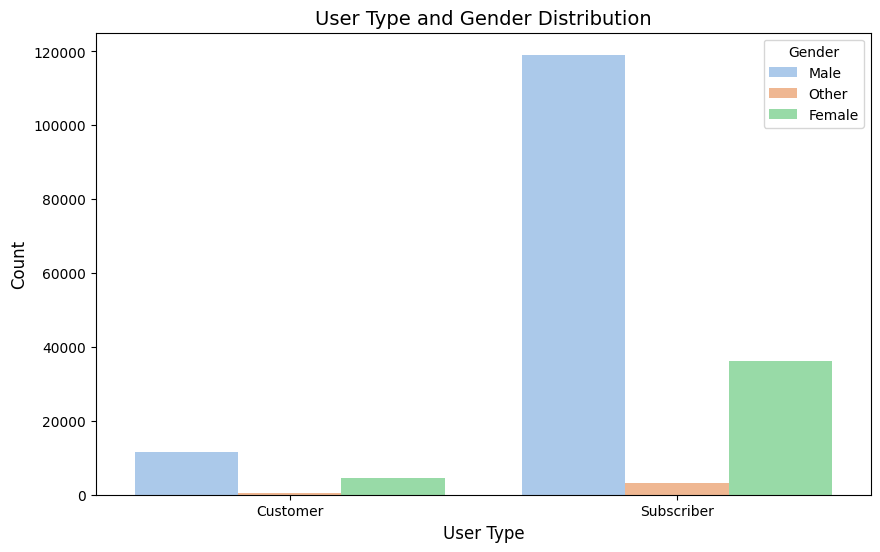

In [4]:
# Visualization 2: User Type and Gender Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='user_type', hue='member_gender', palette='pastel')
plt.title('User Type and Gender Distribution', fontsize=14)
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Gender')
plt.show()

 Comment:
This count plot shows the distribution of user types segmented by gender. Key observations include:

*  Male users are the dominant group among both Subscribers and Customers.

*  Female users form the second largest group, while the "Other" category has the fewest users.

*  Subscribers significantly outnumber Customers across all gender categories.

This visualization highlights the demographic makeup of the user base and the greater popularity of subscriptions over casual use.

## (Visualization 3) Distribution of Trip Durations

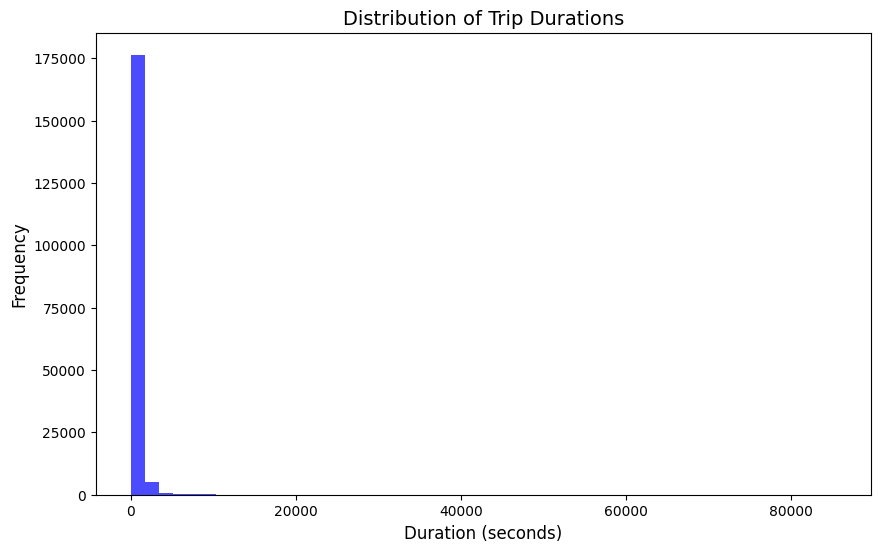

In [5]:
# Visualization 1: Distribution of Trip Durations
plt.figure(figsize=(10, 6))
plt.hist(df['duration_sec'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Trip Durations', fontsize=14)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Comment:
This histogram shows the distribution of trip durations. Most trips are under 2,000 seconds (about 33 minutes), indicating that short rides are the norm. The distribution is highly right-skewed, with a small number of trips extending up to 80,000 seconds—likely outliers or special cases.

Key observations:

*  A sharp peak near the start reflects a high volume of short trips, likely for commuting or quick travel.

*  The long tail on the right suggests the presence of a few unusually long trips, which are rare.

This plot highlights the typical usage pattern of the system: frequent, short-duration rides.

In [6]:
!jupyter nbconvert --to html '/content/Part_II_explanatory_template.ipynb' --output '/content/part_II_notebook.html'


[NbConvertApp] WARNING | pattern '/content/Part_II_explanatory_template.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answ